# QET Simulator on the Imbalanced Maldacena–Qi Model

Numerical demonstration of quantum energy teleportation across a coupled
SYK system — the quantum dual of an eternal traversable wormhole.

**Model:** Haenel, Sahoo, Hsieh & Franz, [arXiv:2102.05687](https://arxiv.org/abs/2102.05687)

$$H_\eta = (1+\eta)\,H^L_{\rm SYK} + (1-\eta)\,H^R_{\rm SYK} + i\mu\sum_j \chi^L_j\chi^R_j$$

**Protocol:** Ikeda, [arXiv:2301.11712](https://arxiv.org/abs/2301.11712)


In [3]:
import numpy as np
from mq_imbalanced import joint_majorana_operators, h_eta_register_pairing
from syk_hamiltonian import generate_couplings, syk_hamiltonian, ground_state_gap
from symmetry import build_sigma_bilinear, build_sigma_quartic
from tfd_state import single_side_spectrum, tfd_pairing, optimal_beta
from qet_protocol import (
    build_local_hamiltonians, verify_locality_condition,
    compute_xi_kappa, energy_extracted_at_theta,
    optimal_theta_sweep, alice_injected_energy, run_qet,
)
from majorana_algebra import majorana_operators

In [ ]:
NQ   = 4
SEED = 7

joint     = joint_majorana_operators(NQ)
couplings = generate_couplings(2 * NQ, seed=SEED)

# Alice on L modes 0-3, Bob on R modes 4-7 (disjoint, required for locality)
MODES_A, MODES_B = (0, 1, 2, 3), (4, 5, 6, 7)
IDX_A,   IDX_B   = (0, 1, 2, 3), (4, 5) #a is quartic, b is bilinear 

print(f"Hilbert space dimension: {joint['dim']}")
print(f"Majoranas per side:      {len(joint['L'])}")
print(f"Independent J_ijkl:      {len(couplings)}")

Hilbert space dimension: 256
Majoranas per side:      8
Independent J_ijkl:      70


## 1. The wormhole Hamiltonian

Build $H_\eta$ at the balanced point ($\eta = 0$) with moderate coupling
and extract its ground state. 

In [5]:
eta, mu = 0.0, 0.3

H    = h_eta_register_pairing(joint, couplings, couplings, eta, mu)
diag = ground_state_gap(H, k=2)
gs   = diag['ground_state']

print(f"eta = {eta},  mu = {mu}")
print(f"ground state energy : {diag['eigenvalues'][0]:.6f}")
print(f"first excited       : {diag['eigenvalues'][1]:.6f}")
print(f"gap                 : {diag['gap']:.6f}   -> gapped (wormhole phase)")
print(f"Hermitian           : {np.allclose((H - H.conj().T).toarray(), 0)}")

eta = 0.0,  mu = 0.3
ground state energy : -1.338528
first excited       : -1.008104
gap                 : 0.330424   -> gapped (wormhole phase)
Hermitian           : True


## 2. The ground state is a thermofield double

The TFD pairing $|n\rangle_L \otimes |\Theta n\rangle_R$ is derived by
diagonalizing the pure coupling term, not constructed by hand

In [6]:
iso      = majorana_operators(NQ)
spectrum = single_side_spectrum(syk_hamiltonian(iso, couplings))
TV       = tfd_pairing(joint, spectrum)

res_tfd = optimal_beta(gs, spectrum, TV)

print(f"optimal inverse temperature  beta* = {res_tfd['beta']:.4f}")
print(f"TFD fidelity  |<gs|TFD>|^2         = {res_tfd['fidelity']:.6f}")
print(f"beta* at search boundary           : {res_tfd['at_boundary']}")

optimal inverse temperature  beta* = 3.5817
TFD fidelity  |<gs|TFD>|^2         = 0.997125
beta* at search boundary           : False


## 3. The Θ selection rule
The correlator that drives the whole protocol,

$$\kappa = \langle g|\,\sigma_A\,\dot\sigma_B\,|g\rangle,
\qquad \dot\sigma_B = i[H,\sigma_B]$$

**vanishes identically unless $\sigma_A$ and $\sigma_B$ have opposite
Θ-parity.** Choose both bilinear (or both quartic) and no energy can be
teleported at all.

In [7]:
loc = build_local_hamiltonians(joint, couplings, couplings, eta, mu,
                               MODES_A, MODES_B, gs)
H_B = loc['H_B']

ops = {
    'bilinear': (build_sigma_bilinear(joint['L'], (0, 1)),
                 build_sigma_bilinear(joint['R'], (4, 5))),
    'quartic':  (build_sigma_quartic(joint['L'], (0, 1, 2, 3)),
                 build_sigma_quartic(joint['R'], (4, 5, 6, 7))),
}

print(f"{'sigma_A':<10} {'sigma_B':<10} {'parity':<10} {'kappa':>14}")
print("-" * 48)
for ta, (sA, _) in ops.items():
    for tb, (_, sB) in ops.items():
        k = compute_xi_kappa(gs, H, H_B, sA, sB)['kappa']
        parity = "same" if ta == tb else "opposite"
        print(f"{ta:<10} {tb:<10} {parity:<10} {k:>14.3e}")

sigma_A    sigma_B    parity              kappa
------------------------------------------------
bilinear   bilinear   same           -1.388e-17
bilinear   quartic    opposite        1.716e-03
quartic    bilinear   opposite        2.468e-03
quartic    quartic    same           -5.551e-16


## 4. The protocol: Alice measures, Bob extracts

With $\sigma_A$ quartic on L and $\sigma_B$ bilinear on R (opposite
parity, so $\kappa \neq 0$), Bob applies

$$U_B(m) = \cos\theta\,\mathbb{1} - i\,m\sin\theta\,\sigma_B$$

conditioned on Alice's outcome $m = \pm 1$. Sweeping $\theta$ over
$[0, 2\pi)$ and evaluating $\langle H_B\rangle$ directly — no closed-form
formula

The point to notice is **$\theta = 0$**: with no operation from Bob,
$\langle H_B\rangle = 0$ exactly. Alice's measurement alone changes
nothing on Bob's side. The classical bit is what unlocks the energy.

In [8]:
import matplotlib.pyplot as plt

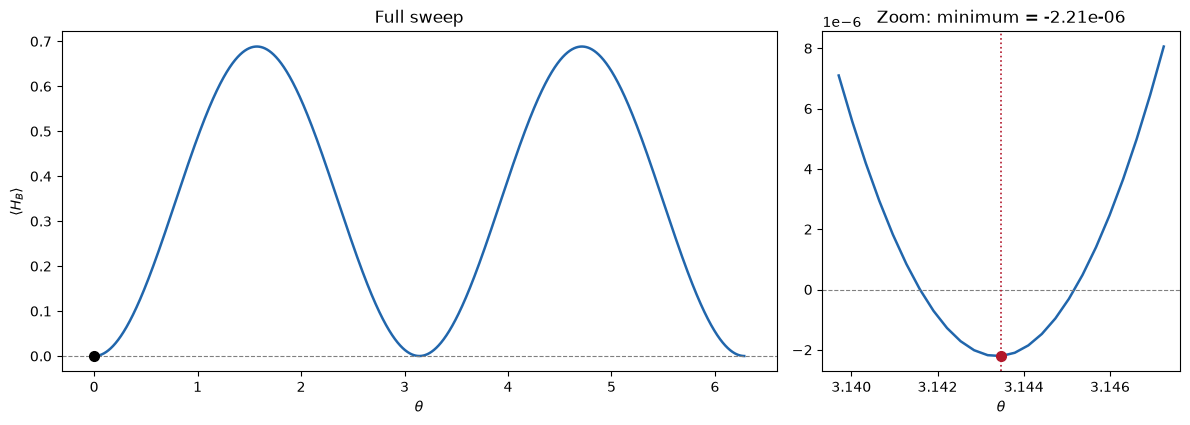

E_A (injected by Alice's measurement) : 5.865267e-01
E_B (extracted by Bob)                : 2.206014e-06
efficiency  E_B / E_A                 : 3.7611e-06
<H_B> at theta = 0                    : -9.133e-16


In [12]:
sigma_A = build_sigma_quartic(joint['L'], IDX_A)
sigma_B = build_sigma_bilinear(joint['R'], IDX_B)

assert verify_locality_condition(H, H_B, sigma_B), "locality condition violated"

sweep = optimal_theta_sweep(gs, H_B, sigma_A, sigma_B, n_points=20000)
fig, (ax, axz) = plt.subplots(1, 2, figsize=(12, 4.5),
                              gridspec_kw={'width_ratios': [2, 1]})

ax.plot(sweep['theta_grid'], sweep['energy_grid'], lw=1.8, color='#2166ac')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.plot(0, sweep['energy_grid'][0], 'o', color='black', ms=7)
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\langle H_B \rangle$")
ax.set_title("Full sweep")


mask = np.abs(sweep['theta_grid'] - sweep['theta']) < 0.004
axz.plot(sweep['theta_grid'][mask], sweep['energy_grid'][mask],
         lw=1.8, color='#2166ac')
axz.axhline(0, color='gray', lw=0.8, ls='--')
axz.axvline(sweep['theta'], color='#b2182b', lw=1.2, ls=':')
axz.set_xlabel(r"$\theta$")
axz.set_title(f"Zoom: minimum = {sweep['energy']:.2e}")
axz.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
axz.plot(sweep['theta'], sweep['energy'], 'o', color='#b2182b', ms=7)
plt.tight_layout()
plt.show()

E_A = alice_injected_energy(gs, H, sigma_A)
E_B = sweep['E_B']

print(f"E_A (injected by Alice's measurement) : {E_A:.6e}")
print(f"E_B (extracted by Bob)                : {E_B:.6e}")
print(f"efficiency  E_B / E_A                 : {E_B/E_A:.4e}")
print(f"<H_B> at theta = 0                    : {sweep['energy_grid'][0]:.3e}")

## 5. Response to the coupling strength

The extracted energy is set by the correlator $\kappa$, and follows

$$E_B \;=\; \tfrac{1}{2}\Big(\xi - \sqrt{\xi^2+\kappa^2}\Big)
\;\approx\; -\frac{\kappa^2}{4\xi}\qquad (\kappa \ll \xi)$$



    mu        gap         xi        kappa          E_B
------------------------------------------------------
  0.05     0.0383     0.3091    1.039e-03    8.728e-07
  0.10     0.0516     0.3637    3.163e-03    6.878e-06
  0.20     0.2033     0.5180    3.617e-03    6.313e-06
  0.30     0.3304     0.6884    2.468e-03    2.212e-06
  0.50     0.5201     1.0570    1.341e-03    4.256e-07
  0.80     0.8126     1.6367    7.669e-04    8.982e-08


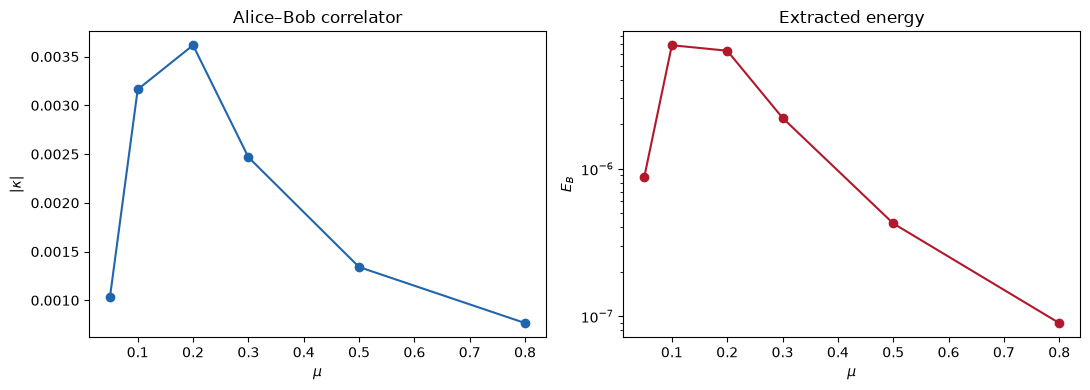

In [14]:
mu_values = [0.05, 0.1, 0.2, 0.3, 0.5, 0.8]
rows = []

for m in mu_values:
    out = run_qet(joint, couplings, couplings, 0.0, m,
                  MODES_A, MODES_B, IDX_A, IDX_B, n_points=2000)
    xi, kap = out['xi'], out['kappa']
    E_B_exact = -0.5 * (xi - np.sqrt(xi**2 + kap**2))
    rows.append((m, out['gap'], xi, kap, E_B_exact))
print(f"{'mu':>6} {'gap':>10} {'xi':>10} {'kappa':>12} {'E_B':>12}")
print("-" * 54)
for m, g, x, k, eb in rows:
    print(f"{m:>6.2f} {g:>10.4f} {x:>10.4f} {k:>12.3e} {eb:>12.3e}")

mus  = [r[0] for r in rows]
kaps = [abs(r[3]) for r in rows]
ebs  = [r[4] for r in rows]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(mus, kaps, 'o-', color='#2166ac')
a1.set_xlabel(r"$\mu$"); a1.set_ylabel(r"$|\kappa|$")
a1.set_title("Alice–Bob correlator")

a2.plot(mus, ebs, 'o-', color='#b2182b')
a2.set_xlabel(r"$\mu$"); a2.set_ylabel(r"$E_B$")
a2.set_yscale('log')
a2.set_title("Extracted energy")

plt.tight_layout(); plt.show()